# **# Franchise Operations Data Analysis**
## Data Cleaning, Exploratory Data Analysis, Visualization and Correlation Analysis

## **Introduction**

This project focuses on analyzing franchise outlet operations using Python and data analysis techniques.

The dataset contains operational information such as monthly footfall, orders, conversion rate, average order value, marketing spend, employee turnover, customer satisfaction, and complaints.

The main purpose of this analysis is to clean the raw data, explore important patterns, visualize the data, and identify relationships between different business variables using correlation analysis.

## **Importing Requried Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

**#Loading Dataset**

The Dataset is stored in Excel File.

Dataframe is named as df.

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/FranchiseOps_AI_Milestone1_Dataset.xlsx')
df

,Record_ID,Outlet_ID,Outlet_Name,Outlet_Type,City,State,Region,Month,Footfall,Orders,...,Sales_Revenue_INR,COGS_INR,Operating_Cost_INR,Marketing_Spend_INR,Profit_INR,Profit_Margin_%,Employees,Employee_Turnover_%,Customer_Satisfaction_1_5,Complaints
0,REC000001,OUT0706,Franchise Outlet 0706,Franchise,Vadodara,Gujarat,West,2024-03,8022.0,1564.0,...,949199.32,490393.08,224520.75,51108.52,183176.97,19.30,7,3.59,3.68,26.0
1,REC000002,OUT0626,Franchise Outlet 0626,Franchise,Bhubaneswar,Odisha,East,2026-01,10528.0,1920.0,...,1540822.01,775200.35,247806.52,87023.69,430791.45,27.96,8,9.63,NaN,24.0
2,REC000003,OUT0296,Franchise Outlet 0296,Franchise,Bhubaneswar,Odisha,East,2026-01,5894.0,1501.0,...,953897.51,609171.21,171678.10,69675.41,103372.80,10.84,21,3.33,3.80,20.0
3,REC000004,OUT0670,Franchise Outlet 0670,Franchise,Pune,Maharashtra,West,2026-01,4275.0,644.0,...,505065.57,294503.07,134141.30,27941.71,48479.50,9.60,14,14.92,3.24,28.0
4,REC000005,OUT0734,Franchise Outlet 0734,Company-Owned,Nagpur,Maharashtra,West,2024-10,10713.0,3235.0,...,3286162.68,1557236.38,955226.50,146944.02,626755.78,19.07,23,5.18,4.16,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30115,REC030116,OUT0162,Franchise Outlet 0162,Franchise,Surat,Gujarat,West,2026-02,4546.0,716.0,...,533132.06,316372.89,81927.67,40809.64,94021.86,17.64,21,10.62,2.87,25.0
30116,REC030117,OUT0463,Franchise Outlet 0463,Franchise,Indore,Madhya Pradesh,West,2025-06,11674.0,3382.0,...,4709212.89,2716838.19,924825.66,118672.80,948876.24,20.15,27,6.51,4.20,16.0
30117,REC030118,OUT0741,Franchise Outlet 0741,Franchise,Kochi,Kerala,South,2025-01,5803.0,1083.0,...,1563779.77,993340.23,436667.25,86323.74,47448.55,3.03,20,13.56,3.29,24.0
30118,REC030119,OUT0225,Franchise Outlet 0225,Franchise,Nashik,Maharashtra,West,2025-03,7990.0,1126.0,...,2075274.12,1339548.48,568715.02,93016.86,73993.76,3.57,7,9.87,3.12,33.0


# **## Understanding the Dataset**

Before performing data cleaning, it is important to understand the structure of the dataset. The following steps examine the information, dimensions, first few records, last records, and descriptive statistics.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30120 entries, 0 to 30119
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Record_ID                  30120 non-null  object 
 1   Outlet_ID                  30120 non-null  object 
 2   Outlet_Name                30120 non-null  object 
 3   Outlet_Type                30120 non-null  object 
 4   City                       30120 non-null  object 
 5   State                      30120 non-null  object 
 6   Region                     30120 non-null  object 
 7   Month                      30120 non-null  object 
 8   Footfall                   29880 non-null  float64
 9   Orders                     29938 non-null  float64
 10  Conversion_Rate_%          29818 non-null  float64
 11  Average_Order_Value_INR    29880 non-null  float64
 12  Sales_Revenue_INR          30120 non-null  float64
 13  COGS_INR                   30120 non-null  flo

In [ ]:
df.describe()

,Footfall,Orders,Conversion_Rate_%,Average_Order_Value_INR,Sales_Revenue_INR,COGS_INR,Operating_Cost_INR,Marketing_Spend_INR,Profit_INR,Profit_Margin_%,Employees,Employee_Turnover_%,Customer_Satisfaction_1_5,Complaints
count,29880.000000,29938.000000,29818.000000,29880.000000,3.012000e+04,3.012000e+04,3.012000e+04,29820.000000,3.012000e+04,30120.000000,30120.000000,29758.000000,29669.00000,29909.000000
mean,6907.465763,1607.975115,22.266748,1136.441544,1.825154e+06,1.003977e+06,4.013059e+05,91183.768682,3.287114e+05,18.018755,17.597510,7.967809,3.45119,22.928583
std,3415.440419,1075.343491,6.418523,386.984856,1.428852e+06,7.980363e+05,3.327136e+05,81594.633265,3.100897e+05,7.609440,5.129945,2.881391,0.57320,6.878751
min,1151.000000,131.000000,7.210000,417.400000,8.276198e+04,4.303380e+04,1.378135e+04,2172.640000,-1.119826e+05,-1.970000,4.000000,1.000000,1.50000,4.000000
25%,4111.000000,787.000000,17.660000,822.922500,8.031996e+05,4.374070e+05,1.678130e+05,35840.095000,1.191360e+05,12.520000,14.000000,5.980000,3.03000,18.000000
50%,6408.000000,1304.000000,21.550000,1149.470000,1.399180e+06,7.636815e+05,2.994239e+05,65372.920000,2.320916e+05,18.040000,17.000000,7.960000,3.44000,22.000000
75%,9338.000000,2182.000000,26.560000,1459.285000,2.411703e+06,1.327392e+06,5.291099e+05,119629.745000,4.353322e+05,23.480000,21.000000,9.960000,3.88000,27.000000
max,18419.000000,7143.000000,46.190000,1941.780000,1.146204e+07,7.031556e+06,3.288607e+06,832533.540000,2.889860e+06,38.770000,34.000000,20.770000,5.00000,56.000000


In [ ]:
df.shape

(30120, 22)

In [ ]:
df.head(2)

,Record_ID,Outlet_ID,Outlet_Name,Outlet_Type,City,State,Region,Month,Footfall,Orders,...,Sales_Revenue_INR,COGS_INR,Operating_Cost_INR,Marketing_Spend_INR,Profit_INR,Profit_Margin_%,Employees,Employee_Turnover_%,Customer_Satisfaction_1_5,Complaints
0,REC000001,OUT0706,Franchise Outlet 0706,Franchise,Vadodara,Gujarat,West,2024-03,8022.0,1564.0,...,949199.32,490393.08,224520.75,51108.52,183176.97,19.30,7,3.59,3.68,26.0
1,REC000002,OUT0626,Franchise Outlet 0626,Franchise,Bhubaneswar,Odisha,East,2026-01,10528.0,1920.0,...,1540822.01,775200.35,247806.52,87023.69,430791.45,27.96,8,9.63,NaN,24.0


In [ ]:
df.tail(1)

,Record_ID,Outlet_ID,Outlet_Name,Outlet_Type,City,State,Region,Month,Footfall,Orders,...,Sales_Revenue_INR,COGS_INR,Operating_Cost_INR,Marketing_Spend_INR,Profit_INR,Profit_Margin_%,Employees,Employee_Turnover_%,Customer_Satisfaction_1_5,Complaints
30119,REC030120,OUT0058,Franchise Outlet 0058,Franchise,Patna,Bihar,East,2025-02,5722.0,1125.0,...,718237.12,393961.49,134173.55,47476.04,142626.04,19.86,13,7.46,3.61,18.0


In [ ]:
df = df.drop(columns=["Record_ID", "Outlet_Name"])
df

,Outlet_ID,Outlet_Type,City,State,Region,Month,Footfall,Orders,Conversion_Rate_%,Average_Order_Value_INR,Sales_Revenue_INR,COGS_INR,Operating_Cost_INR,Marketing_Spend_INR,Profit_INR,Profit_Margin_%,Employees,Employee_Turnover_%,Customer_Satisfaction_1_5,Complaints
0,OUT0706,Franchise,Vadodara,Gujarat,West,2024-03,8022.0,1564.0,19.50,606.90,949199.32,490393.08,224520.75,51108.52,183176.97,19.30,7,3.59,3.68,26.0
1,OUT0626,Franchise,Bhubaneswar,Odisha,East,2026-01,10528.0,1920.0,18.24,802.51,1540822.01,775200.35,247806.52,87023.69,430791.45,27.96,8,9.63,NaN,24.0
2,OUT0296,Franchise,Bhubaneswar,Odisha,East,2026-01,5894.0,1501.0,25.48,635.51,953897.51,609171.21,171678.10,69675.41,103372.80,10.84,21,3.33,3.80,20.0
3,OUT0670,Franchise,Pune,Maharashtra,West,2026-01,4275.0,644.0,15.08,784.26,505065.57,294503.07,134141.30,27941.71,48479.50,9.60,14,14.92,3.24,28.0
4,OUT0734,Company-Owned,Nagpur,Maharashtra,West,2024-10,10713.0,3235.0,30.20,1015.82,3286162.68,1557236.38,955226.50,146944.02,626755.78,19.07,23,5.18,4.16,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30115,OUT0162,Franchise,Surat,Gujarat,West,2026-02,4546.0,716.0,15.77,744.60,533132.06,316372.89,81927.67,40809.64,94021.86,17.64,21,10.62,2.87,25.0
30116,OUT0463,Franchise,Indore,Madhya Pradesh,West,2025-06,11674.0,3382.0,28.97,1392.43,4709212.89,2716838.19,924825.66,118672.80,948876.24,20.15,27,6.51,4.20,16.0
30117,OUT0741,Franchise,Kochi,Kerala,South,2025-01,5803.0,1083.0,18.67,1443.93,1563779.77,993340.23,436667.25,86323.74,47448.55,3.03,20,13.56,3.29,24.0
30118,OUT0225,Franchise,Nashik,Maharashtra,West,2025-03,7990.0,1126.0,14.10,1843.05,2075274.12,1339548.48,568715.02,93016.86,73993.76,3.57,7,9.87,3.12,33.0



**## Handling Missing Values**

Missing values in the numerical columns are replaced with the median value of the respective column.

The median is used because it is less affected by extreme values and outliers compared with the mean.

In [ ]:
df.isnull().sum()

,0
Outlet_ID,0
Outlet_Type,0
City,0
State,0
Region,0
Month,0
Footfall,240
Orders,182
Conversion_Rate_%,302
Average_Order_Value_INR,240


In [ ]:
numeric_columns = [
    "Footfall",
    "Orders",
    "Conversion_Rate_%",
    "Average_Order_Value_INR",
    "Marketing_Spend_INR",
    "Employee_Turnover_%",
    "Customer_Satisfaction_1_5",
    "Complaints"
]

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())


In [ ]:
print(df.isnull().sum())

Outlet_ID                    0
Outlet_Type                  0
City                         0
State                        0
Region                       0
Month                        0
Footfall                     0
Orders                       0
Conversion_Rate_%            0
Average_Order_Value_INR      0
Sales_Revenue_INR            0
COGS_INR                     0
Operating_Cost_INR           0
Marketing_Spend_INR          0
Profit_INR                   0
Profit_Margin_%              0
Employees                    0
Employee_Turnover_%          0
Customer_Satisfaction_1_5    0
Complaints                   0
dtype: int64


In [ ]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (30120, 20)

Data Types:
Outlet_ID                     object
Outlet_Type                   object
City                          object
State                         object
Region                        object
Month                         object
Footfall                     float64
Orders                       float64
Conversion_Rate_%            float64
Average_Order_Value_INR      float64
Sales_Revenue_INR            float64
COGS_INR                     float64
Operating_Cost_INR           float64
Marketing_Spend_INR          float64
Profit_INR                   float64
Profit_Margin_%              float64
Employees                      int64
Employee_Turnover_%          float64
Customer_Satisfaction_1_5    float64
Complaints                   float64
dtype: object


## Converting Month to Date Format

The `Month` column represents monthly observations. It is converted into a proper datetime format so that it can be used effectively for time-series analysis and monthly visualizations.

In [ ]:
df["Month"] = pd.to_datetime(
    df["Month"].astype(str),
    format="%Y-%m",
    errors="coerce"
)

In [ ]:
df.dtypes

,0
Outlet_ID,object
Outlet_Type,object
City,object
State,object
Region,object
Month,datetime64[ns]
Footfall,float64
Orders,float64
Conversion_Rate_%,float64
Average_Order_Value_INR,float64


In [ ]:
df.duplicated().sum()

np.int64(120)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.columns.tolist()

['Outlet_ID',
 'Outlet_Type',
 'City',
 'State',
 'Region',
 'Month',
 'Footfall',
 'Orders',
 'Conversion_Rate_%',
 'Average_Order_Value_INR',
 'Sales_Revenue_INR',
 'COGS_INR',
 'Operating_Cost_INR',
 'Marketing_Spend_INR',
 'Profit_INR',
 'Profit_Margin_%',
 'Employees',
 'Employee_Turnover_%',
 'Customer_Satisfaction_1_5',
 'Complaints']

**## Final Data Quality Check**

After completing the cleaning process, the dataset is checked again for its shape, data types, missing values, and duplicate records.

This confirms that the dataset is ready for exploratory data analysis and visualization.

In [ ]:
df.shape


(30000, 20)

In [ ]:
df.dtypes


,0
Outlet_ID,object
Outlet_Type,object
City,object
State,object
Region,object
Month,datetime64[ns]
Footfall,float64
Orders,float64
Conversion_Rate_%,float64
Average_Order_Value_INR,float64


In [ ]:
df.isnull().sum()


,0
Outlet_ID,0
Outlet_Type,0
City,0
State,0
Region,0
Month,0
Footfall,0
Orders,0
Conversion_Rate_%,0
Average_Order_Value_INR,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# **# Exploratory Data Analysis**

Exploratory Data Analysis (EDA) is performed to understand the distribution and characteristics of the franchise operational variables.

Histograms, boxplots, and time-series graphs are used to identify patterns, variations, and possible outliers in the data.

## Distribution of Numerical Variables

Histograms are used to understand how the numerical variables are distributed. They help identify whether the data is concentrated around certain values and whether the distribution contains unusual patterns.

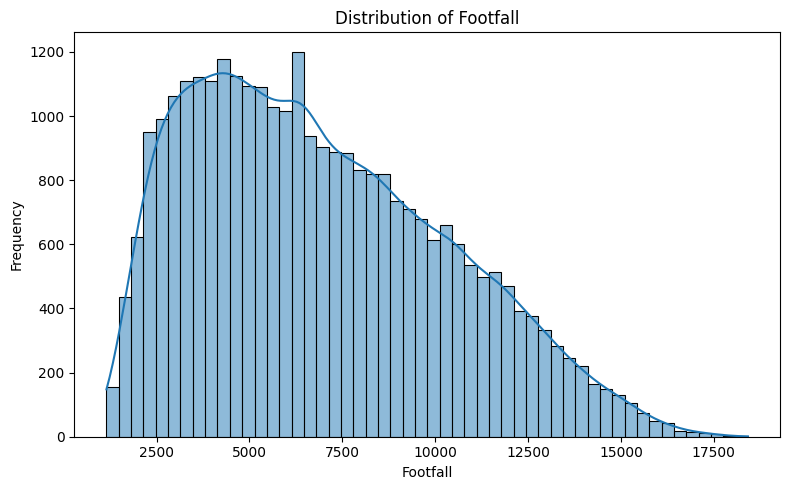

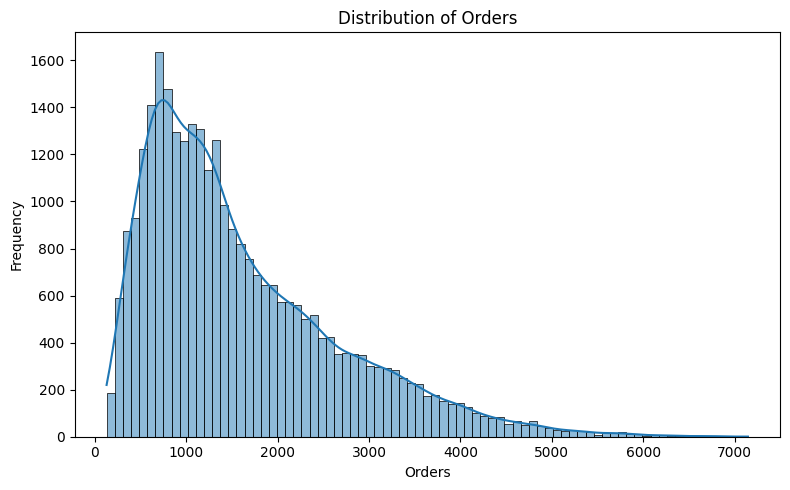

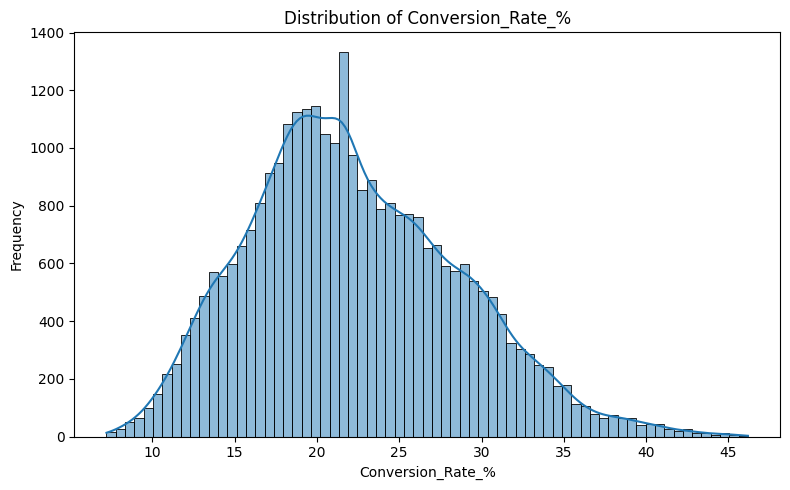

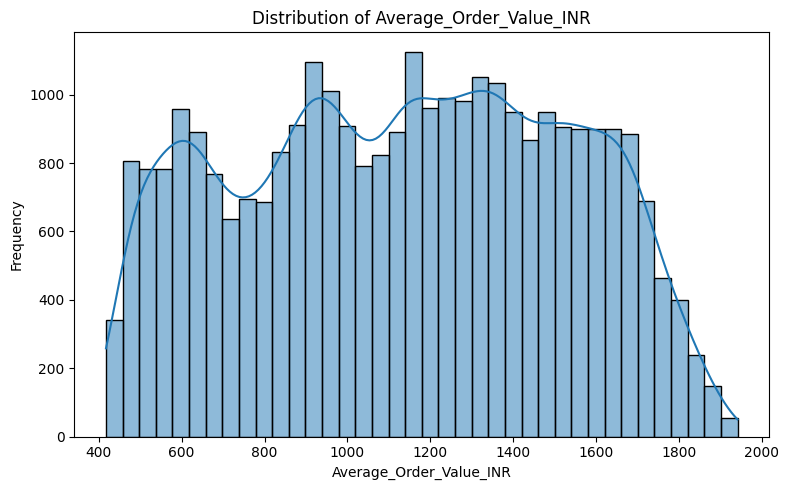

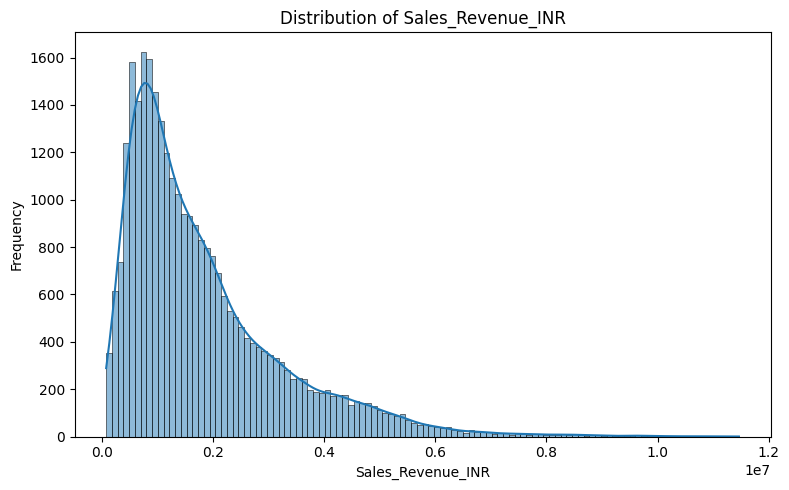

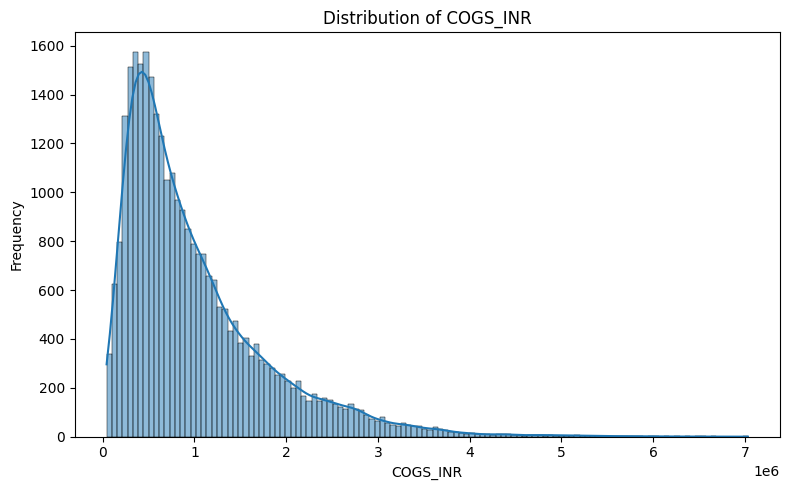

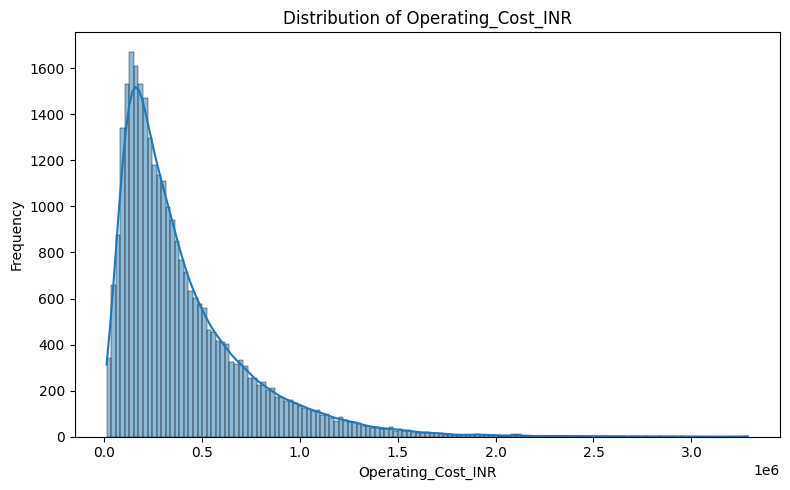

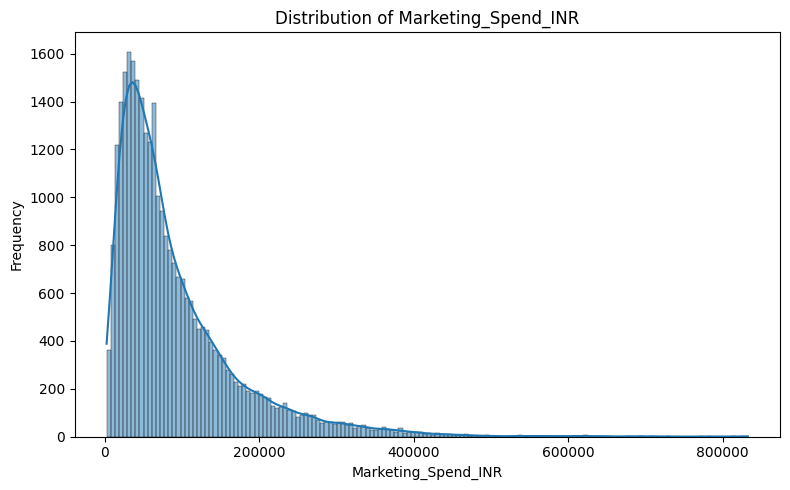

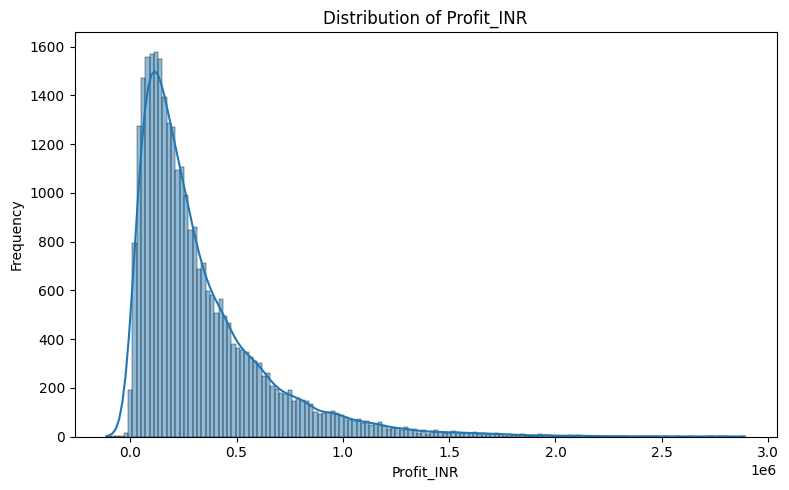

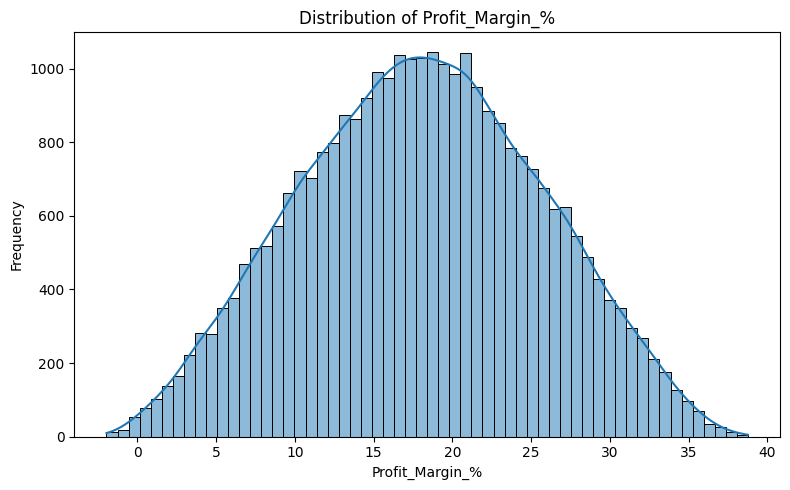

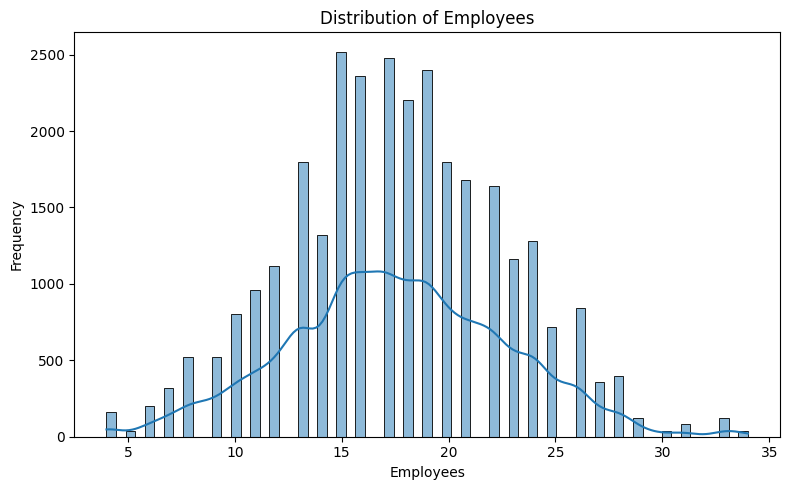

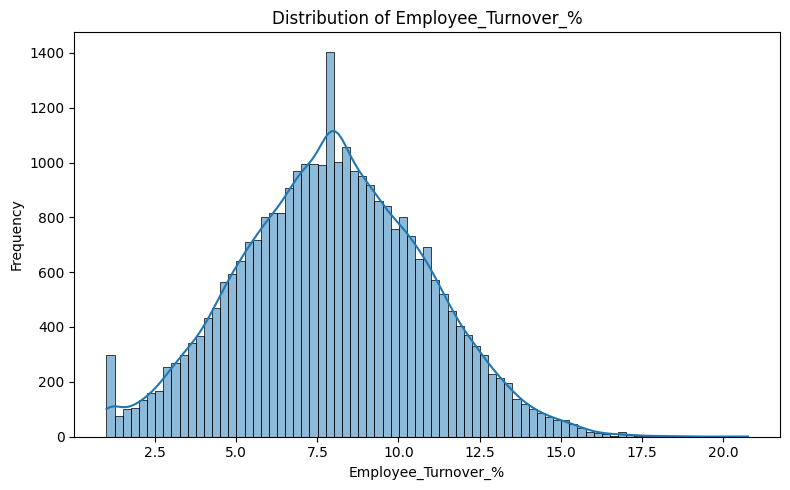

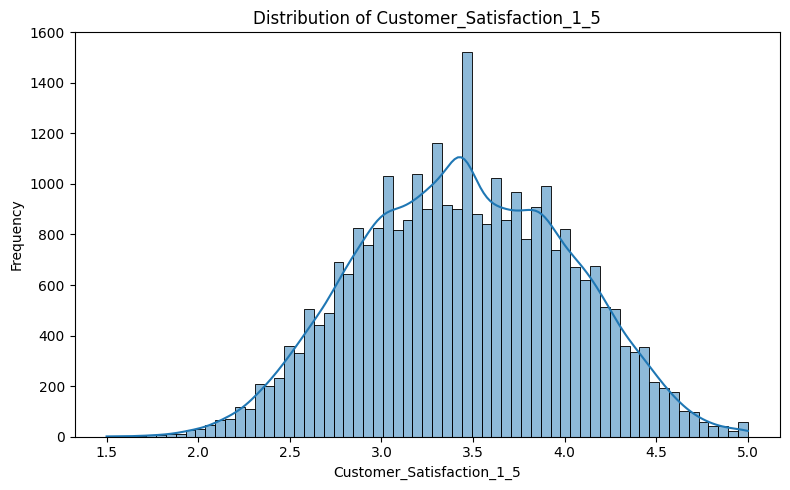

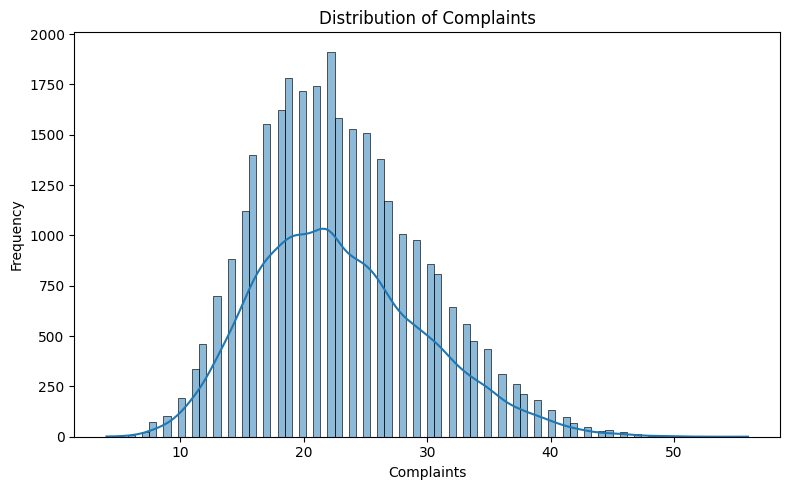

In [ ]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## Boxplot Analysis

Boxplots are used to examine the spread of numerical variables and identify potential outliers.

Outliers represent observations that are considerably different from the majority of the values.

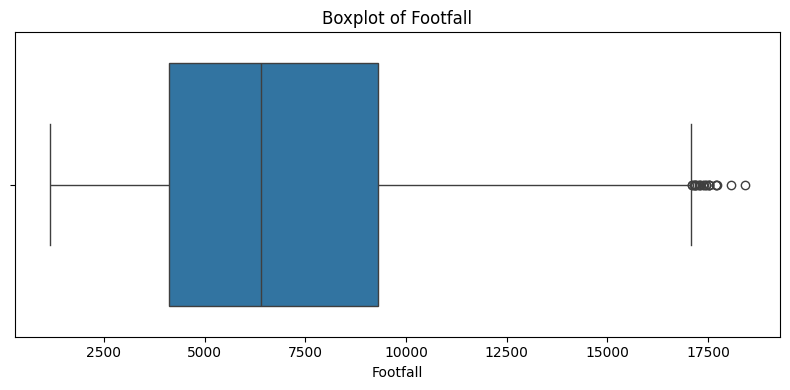

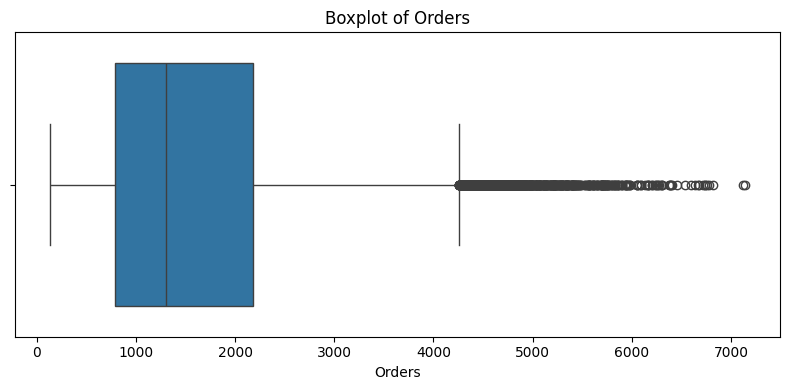

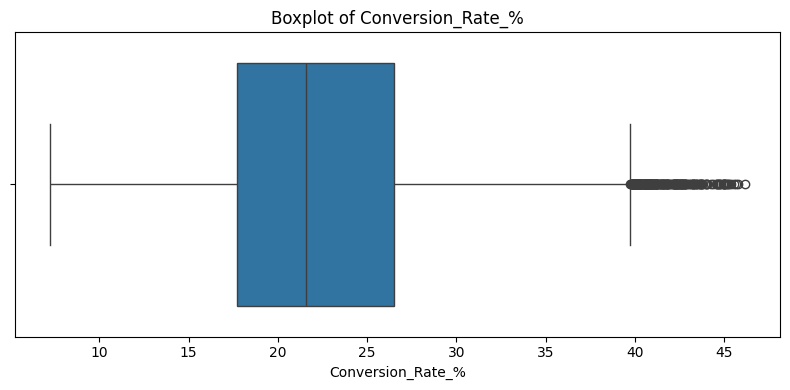

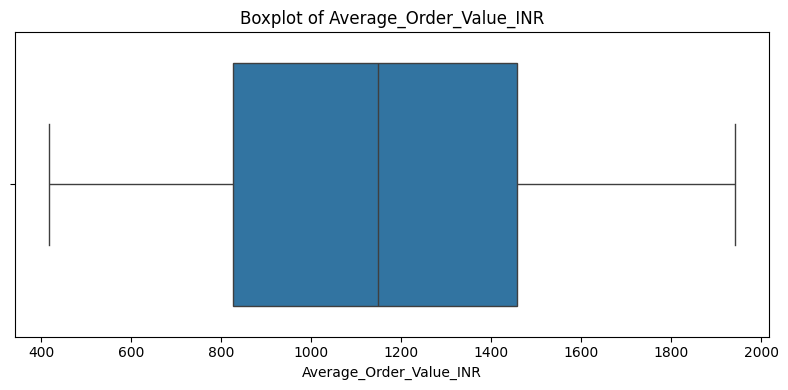

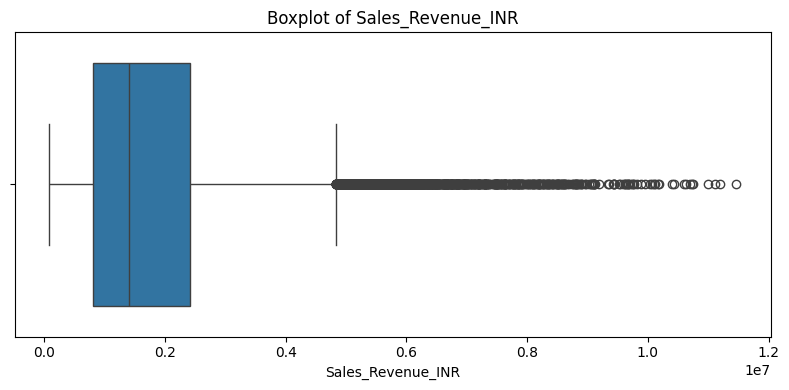

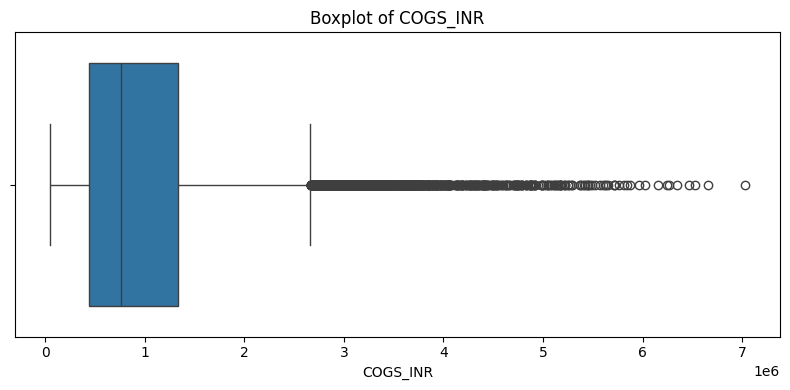

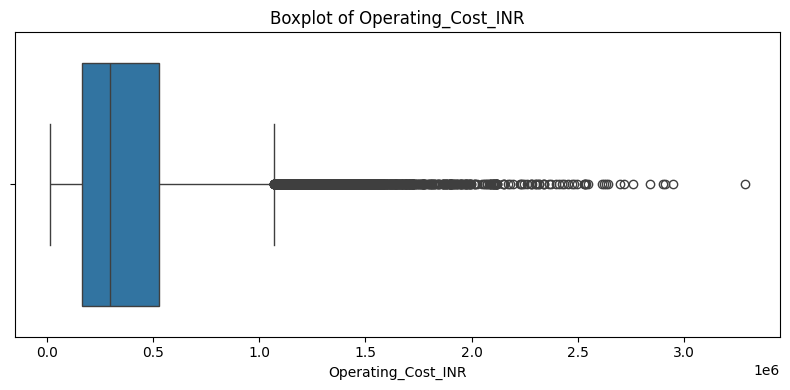

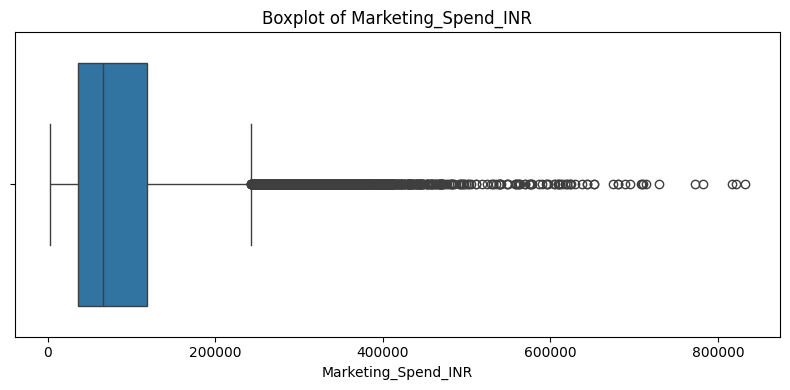

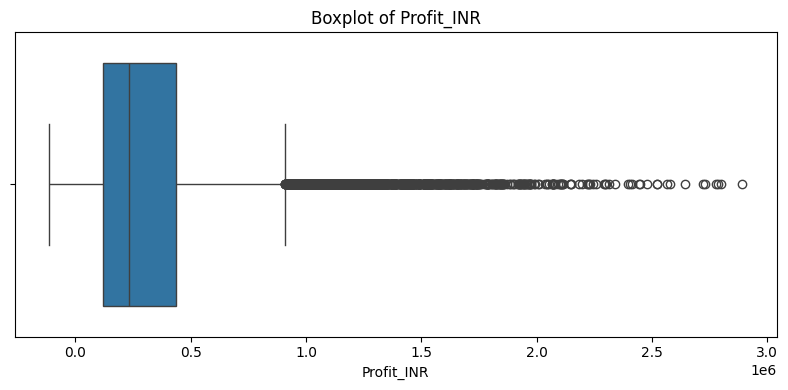

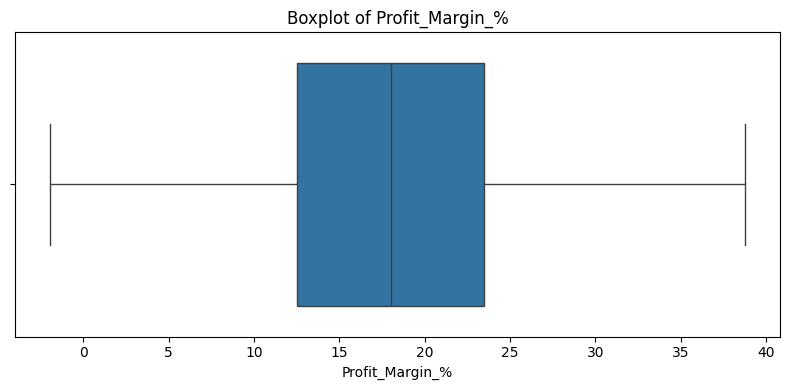

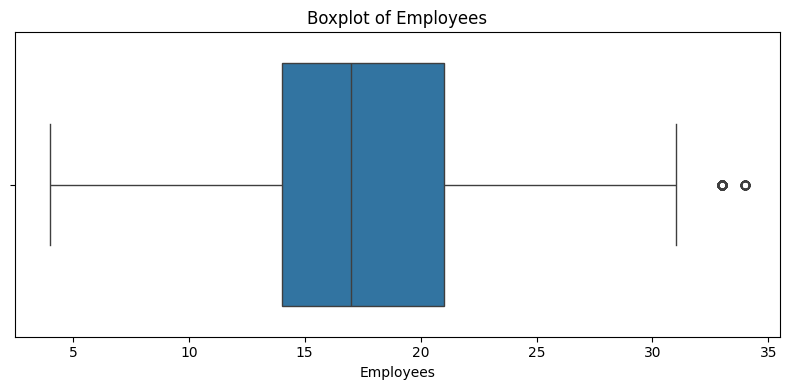

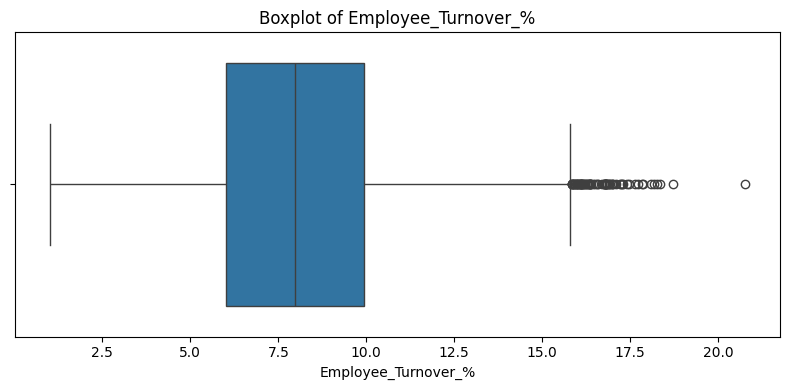

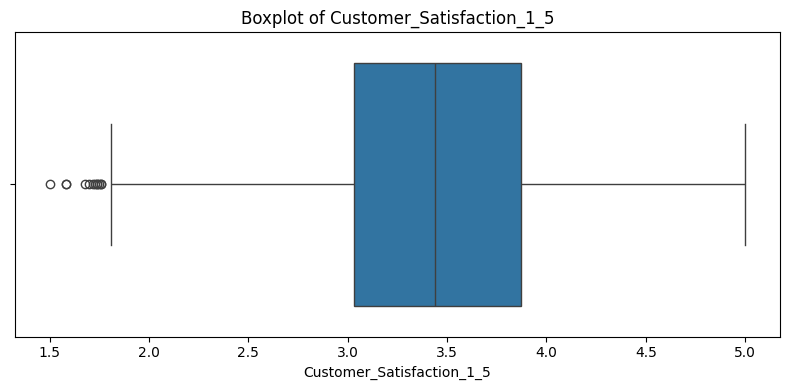

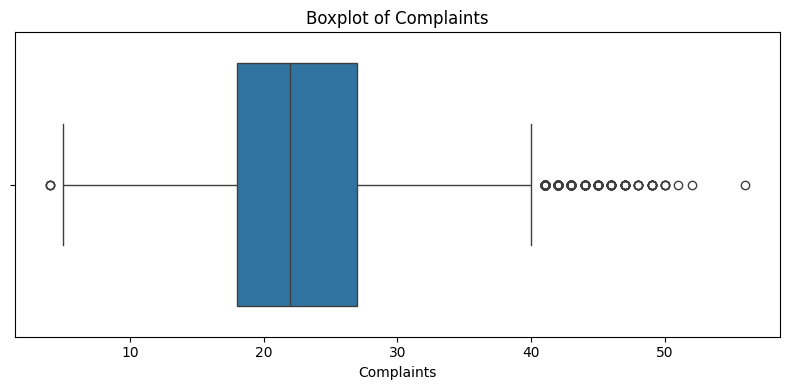

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()